# **1. Pendahuluan**

### **1.1 Intuisi: Komputer tidak selalu memberikan nilai "sempurna"**

Dalam matematika analitik, kita dapat memperoleh hasil seperti

$$ \frac{d}{dx} \sin x = cos x $$

Pada $x=0$

$$ \cos(0) = 1 $$

sehingga nilai eksaknya adalah

$$ f'(0) = 1 $$

Tetapi ketika menggunakan metode numerik, misalnya Forward Difference

$$ f'(x) \approx \frac{f(x+h) - f(x)}{h} $$

kita mungkin memperoleh:

$$ f'(0) \approx 0.99995 $$

Hasil tersebut **bukan 1**, tetapi sangat dekat dengan 1.

Pertanyaannya:

> Apakah 0.99995 merupakan hasil yang bagus?

Untuk menjawabnya kita membutuhkan **error analysis**.

### **1.2 Apa itu Error?**

Secara sederhana:

> Error adalah selisih antara nilai yang kita peroleh dengan nilai sebenarnya.

Misalkan:

$$ x_true = 10 $$

sedangkan hasil numerik:

$$ x_approx = 9.8 $$

Maka terdapat perbedaan:

$$ 10 - 9.8 = 0.2 $$

sehingga error-nya adalah 0.2.

Namun dalam komputasi kita perlu membedakan beberapa jenis error.

### **1.3 Apa itu Ketidakpastian?**

**Ketidakpastian (uncertainty)** berbeda dengan error.

Secara intuitif:

* Error ---> seberapa jauh hasil kita dari hasil sebenarnya.
* Uncertainty ---> seberapa yakin kita terhadap suatu nilai pengukuran/perhitungan.

Contoh eksperimen:

$$ L = 10.0 \ \pm \ 0.1 \ cm $$

Artinya kita memperkirakan panjang benda berada sekitar:

$$ 9.9 \ cm \le L \le 10.1 \ cm $$

Kita tidak mengetahui nilai sebenarnya secara sempurna.

# **2. Jenis-Jenis Error**

### **2.1 True Value dan Approximate Value**

**True value**

Nilai sebenarnya atau nilai eksak:

$$ x_{true} $$

**Approximate value**

Nilai pendekatan yang diperoleh dari metode numerik:

$$ x_{approx} $$

### **2.2 Absolute Error**

Absolute error hanya melihat **seberapa besar perbedaan secara absolute**.

Rumus:

$$ \boxed{E_{absolute} = |x_{true} - x_{approx}|} $$

### **2.3 Relative Error**

Absolute error terkadang tidak cukup. Karena itu kita menggunakan Relative error.

$$ \boxed{E_{relative} = \frac{|x_{true} - x_{approx}|}{|x_{true}|}} $$

### **2.4 Percentage Error**

Relative error dapat dinyatakan dalam persen:

$$ \boxed{E_{\%} = E_{relative} \times 100\%} $$

In [1]:
def error_analysis(true_value, approximate_value):

    absolute_error = abs(true_value - approximate_value)

    relative_error = absolute_error / abs(true_value)

    percentage_error = relative_error * 100

    return absolute_error, relative_error, percentage_error

In [2]:
true_value = 10
approximate_value = 9.8

abs_error, rel_error, percent_error = error_analysis(
    true_value,
    approximate_value
)

print("Absolute error   =", abs_error)
print("Relative error   =", rel_error)
print("Percentage error =", percent_error, "%")

Absolute error   = 0.1999999999999993
Relative error   = 0.019999999999999928
Percentage error = 1.9999999999999927 %


### **2.5 Truncation Error**

**Truncation error** muncul ketika suatu proses matematika yang sebenarnya tak hingga kita **potong menjadi bentuk terbatas**.

Ini berhubungan langsung dengan **Deret Taylor**.

Misalnya:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2!}f''(x) + \frac{h^3}{3!}f'''(x) + \dots$$

Jika kita hanya menggunakan:

$$f(x+h) \approx f(x) + hf'(x)$$

maka suku-suku berikutnya:

$$\frac{h^2}{2}f''(x) + \dots$$

diabaikan.

Pengabaian tersebut menghasilkan **truncation error**.

### **2.6 Round-off Error**

Berbeda dengan truncation error.

Round-off error berasal dari keterbatasan komputer dalam merepresentasikan bilangan.

Misalnya secara matematis:

$$\frac{1}{3} = 0.33333333333333333\dots$$

Bilangan tersebut mempunyai digit tak hingga.

Tetapi komputer hanya menyimpan jumlah digit terbatas.

Sehingga komputer menyimpan pendekatan:

$$0.333333333333333331\dots$$

Ada sedikit perbedaan.

Itulah **round-off error**.

# **3. Floating Point dan Round-off Error**

Sekarang kita masuk sedikit ke bagaimana komputer menyimpan angka.

### **3.1 Intuisi**

Komputer tidak menyimpan bilangan real seperti manusia menulis:

$$ 3.1415926535897932384626... $$

Komputer menggunakan representasi **floating-point**.

Secara konseptual:

$$ x = \pm m \times b^e $$

dengan:  
* $m$ = significand/mantissa;
* $b$ = basis;
* $e$ = exponent.  

Untuk floating-point standar komputer modern, basis yang umum digunakan adalah:

$$ b = 2 $$

Karena komputer bekerja menggunakan sistem biner.

### **3.2 Contoh sederhana**

Misalkan komputer hanya mampu menyimpan 4 digit:

$$ 3.141592... $$

akan disimpan sebagai:

$$ 3.142 $$

Perbedaannya:

$$ |3.141592 − 3.142| $$

adalah round-off error.

Dalam komputer modern, jumlah digit yang tersedia jauh lebih banyak, tetapi prinsipnya sama.

### **3.3 Mengapa operasi aritmetika juga dapat menghasilkan error?**

Misalnya:

$$ a = 0.1 \ \text{dan} \ b = 0.2 $$

secara matematis:

$$ a + b = 0.3 $$

Tetapi pada representasi floating-point tertentu, 0.1 dan 0.2 tidak dapat direpresentasikan secara biner dengan tepat.

Karea itu Python dapat menunjukkan:

In [3]:
a = 0.1
b = 0.2

print(a + b)

0.30000000000000004


Bukan karena Python "salah menghitung".

Ini merupakan konsekuensi dari **floating-point representation**.

# **4. Truncation Error dan Deret Taylor**

### **4.1 Forward Difference**

Kita mulai dari Deret Taylor:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \dots$$

Susun ulang:

$$f'(x) = \frac{f(x+h) - f(x)}{h} - \frac{h}{2}f''(x) - \frac{h^2}{6}f'''(x) - \dots$$

Jika kita menggunakan pendekatan:

$$\boxed{f'(x) \approx \frac{f(x+h) - f(x)}{h}}$$

kita mengabaikan:

$$-\frac{h}{2}f''(x) - \dots$$

Sehingga truncation error utamanya:

$$\boxed{E_T = O(h)}$$

Jadi **Forward Difference adalah orde pertama**.

### **4.2 Backward Difference**

Gunakan Deret Taylor:

$$f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \dots$$

Sehingga:

$$f'(x) = \frac{f(x) - f(x-h)}{h} + \frac{h}{2}f''(x) - \dots$$

Dengan pendekatan:

$$\boxed{f'(x) \approx \frac{f(x) - f(x-h)}{h}}$$

truncation error utamanya:

$$\boxed{E_T = O(h)}$$

Jadi Backward Difference juga **orde pertama**.

### **4.3 Central Difference**

Sekarang sesuatu yang menarik.

Gunakan dua ekspansi Taylor:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \dots$$

dan:

$$f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \dots$$

Kurangkan:

$$f(x+h) - f(x-h) = 2hf'(x) + \frac{h^3}{3}f'''(x) + \dots$$

Sehingga:

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h} - \frac{h^2}{6}f'''(x) - \dots$$

Maka:

$$\boxed{f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}}$$

dengan truncation error:

$$\boxed{E_T = O(h^2)}$$

Ini menjelaskan mengapa Central Difference biasanya jauh lebih akurat daripada Forward dan Backward Difference untuk $h$ yang sama.

# **5. Comvergence dan Order of Accuracy**

### **5.1 Intuisi**

Bayangkan kita menghitung turunan dengan:

$$ h = 0.1, \ h = 0.01, \ h = 0.001 $$

Jika hasilnya semakin mendekati solusi eksak, kita mengatakan metode tersebut **convergent**.

Secara sederhana:

$$h \rightarrow 0$$

maka:

$$f_{\text{numerik}} \rightarrow f_{\text{exact}}$$

### **5.2 Apa arti $O(h)$?**

Jika:

$$E \sim Ch$$

maka kita katakan:

$$\boxed{E = O(h)}$$

Artinya ketika $h$ diperkecil 10 kali, error kira-kira juga berkurang 10 kali.

Contoh:

$$h = 0.1$$

error:

$$E \approx 0.01$$

Jika:

$$h = 0.01$$

maka kira-kira:

$$E \approx 0.001$$

### **5.3 $O(h^2)$**

Jika:

$$E \sim Ch^2$$

maka:

$$E = O(h^2)$$

Ketika $h$ diperkecil 10 kali:

$$h \rightarrow \frac{h}{10}$$

maka:

$$E \rightarrow \frac{E}{100}$$

Jadi metode $O(h^2)$ jauh lebih cepat mengurangi truncation error.

# **6. Truncation Error vs Round-off Error**

Ini salah satu konsep **paling penting** dalam Fisika Komputasi.

Mungkin Anda berpikir:

> "Kalau $h$ semakin kecil, bukankah hasil numerik semakin akurat?"

**Tidak selalu.**

Justru pada suatu titik, memperkecil $h$ dapat membuat hasil **semakin buruk**.

Ada dua sumber error utama:

$$ \boxed{E_{total} \approx E_{truncation} + E_{round-off}} $$

Untuk metode turunan numerik:

**Truncation error**

Biasanya:

$$E_T \sim C h^p$$

Semakin kecil $h$:

$$E_T \downarrow$$

Bagus.

Tetapi:

**Round-off error**

Untuk operasi:

$$\frac{f(x+h) - f(x)}{h}$$

ketika $h$ sangat kecil, kita mengurangkan dua bilangan yang hampir sama:

$$f(x+h) \approx f(x)$$

Selisihnya sangat kecil.

Kesalahan floating-point dapat menjadi signifikan dibandingkan selisih tersebut.

Secara kasar:

$$E_R \sim \frac{C \epsilon}{h}$$

dengan $\epsilon$ adalah machine precision.

Jadi:

$$\boxed{E_{\text{total}} \sim C h^p + \frac{C' \epsilon}{h}}$$


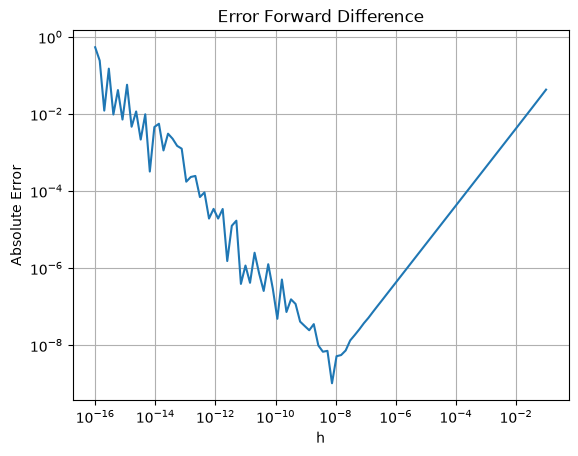

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

def exact(x):
    return np.cos(x)

def forward_difference(x, h):
    return (f(x + h) - f(x)) / h

x = 1.0

h_values = np.logspace(-16, -1, 100)

errors = []

for h in h_values:
    numerical = forward_difference(x, h)
    error = abs(numerical - exact(x))
    errors.append(error)

plt.loglog(h_values, errors)
plt.xlabel("h")
plt.ylabel("Absolute Error")
plt.title("Error Forward Difference")
plt.grid(True)
plt.show()

# **7. Accuracy, Precision, Stability, Conditioning, Convergence**

### **7.1 Accuracy**

Accuracy = kedekatan terhadap nilai sebenarnya.

Misalnya:

$$ x_{true} = 10 $$

hasil:

$$ 9.99 $$

maka hasil tersebut cukup akurat.

### **7.2 Precision**

Precision = konsistensi hasil atau kemampuan menghasilkan nilai yang sangat detail/konsisten.

Misalnya sebuah metode menghasilkan:

$$ 9.001, \ 9.002, \ 9.001 $$

hasilnya konsisten, tetapi belum tentu  dekat denga nilai sebenarnya.

Jadi:

> Precision tidak selalu berarti accuracy

### **7.3 Stability**

Stability berkaitan dengan bagaimana error kecil dalam proses komputasi memengaruhi hasil.

Metode yang stabil:

> error kecil tidak berkembang menjadi error besar secara tidak terkendali.

Ini sangat penting dalam simulasi persamaan diferensial.

Misalnya pada simulasi:

$$ x_{n+1} = x_n + hf(x_{n}) $$

yang merupakan metode Euler.

Pemilihan $h$ yang tidak tepat dapat membuat solusi menjadi tidak stabil.

### **7.4 Conditioning**

Conditioning berhubungan dengan **masalah matematisnya**, bukan terutama algoritmanya.

Misalnya kita mempunyai:

$$ y = f(x) $$

Jika perubahan kecil $x$ menghasilkan perubahan besar pada $y$, maka masalah tersebut **ill-conditioned**.

Sebaliknya jika perubahan kecil pada input hanya menghasilkan perubahan kecil pada output:

$$ well-conditioned $$

### **7.5 Convergence**

Convergence berarti solusi numerik mendekati solusi eksak ketika parameter diskritisasi diperbaiki.

Misalnya:

$$h \rightarrow 0$$

dan:

$$f_{\text{numerik}} \rightarrow f_{\text{exact}}$$

maka metode tersebut convergent.

---

**Ringkasan perbedaannya**

| Konsep | Pertanyaan |
| :--- | :--- |
| Accuracy | Seberapa dekat hasil dengan nilai sebenarnya? |
| Precision | Seberapa konsisten/detail hasil? |
| Stability | Apakah error tetap terkendali selama komputasi? |
| Conditioning | Seberapa sensitif masalah terhadap perubahan input? |
| Convergence | Apakah solusi numerik mendekati solusi eksak? |

# **8. Implemetasi Python**

Fungsi yang akan digunakan:

$$ f(x) = \sin(x) $$

sehingga:

$$ f'(X) = \cos(x) $$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

def exact_deriavtive(x):
    return np.cos(x)

def forward_difference(x, h):
    return (f(x + h) - f(x)) / h

def backward_difference(x, h):
    return (f(x) - f(x - h)) / h

def central_difference(x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

In [5]:
x = 1.0

exact = exact_deriavtive(x)

h = 0.01

forward = forward_difference(x, h)
backward = backward_difference(x, h)
central = central_difference(x, h)

print(f"exact    = {exact}")
print(f"Forward  = {forward}")
print(f"Backward = {backward}")
print(f"Central  = {central}\n")

print(f"Forward Error   = {abs(forward - exact)}")
print(f"Backward Error   = {abs(backward - exact)}")
print(f"Central Error   = {abs(central - exact)}")

exact    = 0.5403023058681398
Forward  = 0.536085981011869
Backward = 0.544500620737598
Central  = 0.5402933008747335

Forward Error   = 0.00421632485627077
Backward Error   = 0.004198314869458208
Central Error   = 9.004993406280803e-06


$$ \text{Forward} = O(h) $$

$$ \text{Backward} = O(h) $$

$$ \text{Central} = O(h^2) $$

In [6]:
h_values = np.logspace(-1, -6, 20)

forward_errors = []
backward_errors = []
central_errors = []

exact = exact_deriavtive(x)

for h in h_values:
    forward = forward_difference(x, h)
    backward = backward_difference(x, h)
    central = central_difference(x, h)

    forward_errors.append(abs(forward - exact))
    backward_errors.append(abs(backward - exact))
    central_errors.append(abs(central - exact))

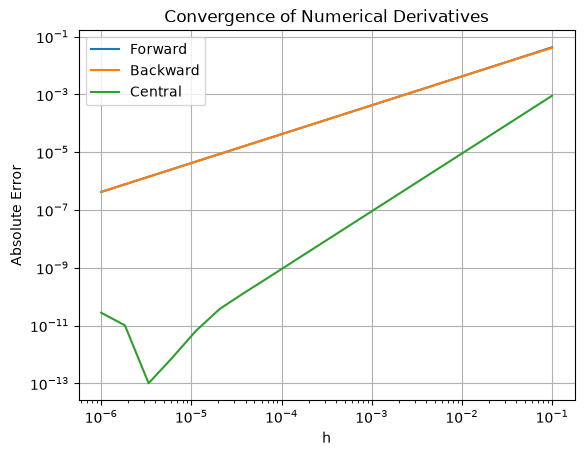

In [7]:
plt.loglog(h_values, forward_errors, label="Forward")
plt.loglog(h_values, backward_errors, label="Backward")
plt.loglog(h_values, central_errors, label="Central")

plt.xlabel("h")
plt.ylabel("Absolute Error")

plt.title("Convergence of Numerical Derivatives")

plt.legend()
plt.grid(True)

plt.show()